# Hybrid physics + ML: learning a parameterization inside a process-based model

A minimal, self-contained demonstration of **hybrid modelling**: keep the trustworthy
**dynamical core** of a process-based model, and replace the uncertain
**parameterization** (the "closure") with a small neural network trained on data.

Using a damped nonlinear pendulum as the toy system, we compare four ways of supplying
the unresolved process and show why the hybrid (physics core + learned closure)
generalizes best — the same design used by ML subgrid parameterizations in modern
weather and climate models (e.g. Rasp et al. 2018; Bolton & Zanna 2019; NeuralGCM,
Kochkov et al. 2024). See `docs/parameterization_closure_notes.md` for the background
theory (the closure problem, and the taxonomy of hybrid designs).

**Requirements:** `numpy`, `scikit-learn`, `matplotlib` — see `requirements.txt`.


In [1]:
# If a package is missing:  pip install -r ../requirements.txt
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(0)


## 1. The toy "real world": a damped nonlinear pendulum

State: angle $\theta$ and angular velocity $\omega=\dot\theta$. The true dynamics are

$$\dot\theta = \omega, \qquad
  \dot\omega = \underbrace{-\tfrac{g}{L}\sin\theta}_{\text{dynamical core (known exactly)}}
  \;\underbrace{-\,k\,\omega\,|\omega|}_{\text{unresolved drag = the parameterized process}}.$$

- The **dynamical core** is the gravity restoring force. We know it exactly.
- The **drag** $-k\,\omega|\omega|$ is an **unresolved process**. In a real model this
  dissipative term would be supplied by a hand-tuned **parameterization** scheme. Here the
  model is *not told* this term: it is exactly the "closure" the model must learn.

This is the **closure problem** in miniature: a model that knows only the core needs a
parameterization to stand in for the process it cannot resolve.


In [2]:
G_OVER_L = 9.81      # gravity / length  (restoring-force strength)
K_DRAG   = 0.50      # true quadratic-drag coefficient (the "unresolved" process)

def core_accel(theta):
    """The trusted DYNAMICAL CORE: gravity restoring force only (known exactly)."""
    return -G_OVER_L * np.sin(theta)

def true_accel(theta, omega):
    """The full 'real-world' acceleration = core + the unresolved nonlinear drag."""
    return core_accel(theta) - K_DRAG * omega * np.abs(omega)

## 2. Time-stepping the model (RK4)

Given any acceleration model `accel_fn(theta, omega)` returning $\dot\omega$, we integrate
the state $(\theta,\omega)$ forward with classic 4th-order Runge-Kutta. Every model below
(physics, classic, pure-ML, hybrid) is run through this *same* integrator, so the only thing
that changes between them is how $\dot\omega$ is computed.

In [3]:
def integrate(accel_fn, theta0, omega0, dt, n):
    """Integrate the pendulum with a given acceleration model. Returns theta[t], omega[t]."""
    th = np.empty(n + 1); om = np.empty(n + 1)
    th[0], om[0] = theta0, omega0
    for i in range(n):
        def deriv(t, w):                          # state (theta, omega) -> (dtheta, domega)
            return w, accel_fn(t, w)
        k1 = deriv(th[i],                om[i])
        k2 = deriv(th[i] + 0.5*dt*k1[0], om[i] + 0.5*dt*k1[1])
        k3 = deriv(th[i] + 0.5*dt*k2[0], om[i] + 0.5*dt*k2[1])
        k4 = deriv(th[i] +     dt*k3[0], om[i] +     dt*k3[1])
        th[i+1] = th[i] + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        om[i+1] = om[i] + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    return th, om

## 3. Generate "high-resolution truth" training data

We run the *true* system from several moderate-amplitude initial angles and record, at every
step, the pair $(\theta,\omega)$ and the **true acceleration** $\dot\omega$. These tendency
pairs are the training data, exactly how an ML parameterization is trained offline on
high-resolution simulations (or observations).

The quantity the parameterization must supply is the **residual**

$$\text{drag} = \dot\omega_\text{true} - \big(-\tfrac{g}{L}\sin\theta\big),$$

i.e. everything the dynamical core does *not* already account for.

In [4]:
dt, T = 0.02, 20.0
n_steps = int(T / dt)
train_ics = [0.4, 0.6, 0.8, 1.0, 1.2]            # training amplitudes (radians)

TH, OM, ACC = [], [], []
for th0 in train_ics:
    th, om = integrate(true_accel, th0, 0.0, dt, n_steps)
    TH.append(th); OM.append(om); ACC.append(true_accel(th, om))
TH = np.concatenate(TH); OM = np.concatenate(OM); ACC = np.concatenate(ACC)

X    = np.column_stack([TH, OM])                 # NN inputs: (theta, omega), shape (N, 2)
DRAG = ACC - core_accel(TH)                       # residual the parameterization must supply
print(f"training samples: {X.shape[0]}   (theta in [{TH.min():.2f}, {TH.max():.2f}] rad)")

training samples: 5005   (theta in [-0.64, 1.20] rad)


## 4. Four ways to supply the parameterization

1. **Physics-only** : core only, no drag. Energy is conserved, so it never decays.
2. **Classic parameterization** : core + *linear* drag $-c\,\omega$, with the single
   coefficient $c$ fit by least squares. This is the traditional hand-tuned scheme.
3. **Pure ML (black box)** : $\dot\omega = \text{NN}_\text{full}(\theta,\omega)$, learning the
   *entire* acceleration and ignoring the known physics.
4. **Hybrid (learned parameterization)** : core $+\,\text{NN}_\text{drag}(\theta,\omega)$, keeping
   gravity exact and learning *only* the drag closure — the "learned physics" hybrid design.


In [5]:
# (2) classic parameterization: residual ~ -c*omega  ->  least-squares c
c_lin = -np.sum(DRAG * OM) / np.sum(OM**2)
print(f"fitted linear-drag coefficient c = {c_lin:.4f}   (true law is nonlinear: -k*w*|w|)")

# (3) pure ML: learn the FULL acceleration from (theta, omega)
nn_full = make_pipeline(StandardScaler(),
                        MLPRegressor(hidden_layer_sizes=(64, 64), activation="tanh",
                                     max_iter=4000, random_state=0))
nn_full.fit(X, ACC)

# (4) hybrid: learn ONLY the drag residual (the closure) from (theta, omega)
nn_drag = make_pipeline(StandardScaler(),
                        MLPRegressor(hidden_layer_sizes=(32, 32), activation="tanh",
                                     max_iter=4000, random_state=0))
nn_drag.fit(X, DRAG)

fitted linear-drag coefficient c = 0.6132   (true law is nonlinear: -k*w*|w|)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('mlpregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_net

In [6]:
# assemble the four acceleration models (each maps (theta, omega) -> domega/dt)
def m_physics(t, w):  return core_accel(t)                                       # 1
def m_classic(t, w):  return core_accel(t) - c_lin * w                           # 2
def m_pureml(t, w):   return float(nn_full.predict([[t, w]])[0])                 # 3
def m_hybrid(t, w):   return core_accel(t) + float(nn_drag.predict([[t, w]])[0]) # 4

models = {"physics-only":                    m_physics,
          "classic param (linear drag)":     m_classic,
          "pure ML (black box)":             m_pureml,
          "hybrid (physics + learned drag)": m_hybrid}

## 5. Test on a held-out, larger-amplitude trajectory (generalization)

We start from $\theta_0 = 2.5$ rad, **outside** the training range ($\le 1.2$ rad). This tests
*generalization*, not just fitting: at large angles $\sin\theta$ is strongly nonlinear, so the
black-box model must extrapolate the dominant restoring force it learned from data, while the
hybrid has that force hard-wired and only extrapolates the small drag correction.

In [7]:
theta0_test = 2.5
th_true, om_true = integrate(true_accel, theta0_test, 0.0, dt, n_steps)

print(f"Test initial angle = {theta0_test} rad (training used <= {max(train_ics)} rad)\n")
print(f"{'model':<34}{'RMSE in theta(t)':>18}")
print("-" * 52)
results = {}
for name, fn in models.items():
    th_m, _ = integrate(fn, theta0_test, 0.0, dt, n_steps)
    rmse = np.sqrt(np.mean((th_m - th_true) ** 2))
    results[name] = (th_m, rmse)
    print(f"{name:<34}{rmse:>18.4f}")
best = min(results, key=lambda k: results[k][1])
print("-" * 52); print(f"best model: {best}")

Test initial angle = 2.5 rad (training used <= 1.2 rad)

model                               RMSE in theta(t)
----------------------------------------------------
physics-only                                  1.8228
classic param (linear drag)                   0.1800
pure ML (black box)                           0.1603


hybrid (physics + learned drag)               0.1179
----------------------------------------------------
best model: hybrid (physics + learned drag)


## 6. Look at the trajectories and the learned parameterization

**Left:** $\theta(t)$ for the truth and all four models on the held-out trajectory.
**Right:** the parameterization itself as a function of $\omega$ (at $\theta=0$): the true
nonlinear drag, the classic linear fit, and the learned NN. Inside the training $\omega$ range
(grey band) all three agree; outside it, both fits underestimate the true quadratic drag.

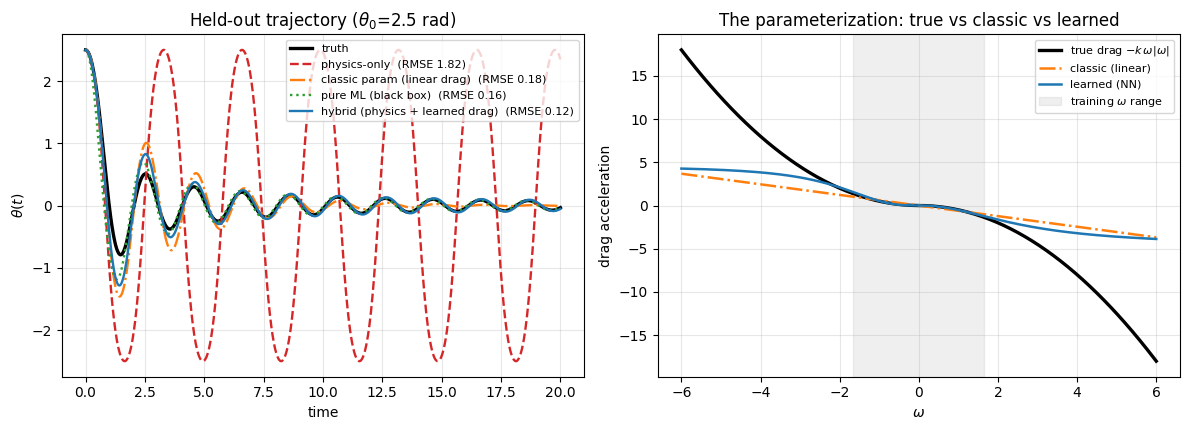

In [8]:
t = np.arange(n_steps + 1) * dt
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

ax[0].plot(t, th_true, "k", lw=2.4, label="truth")
styles = {"physics-only": ("C3", "--"), "classic param (linear drag)": ("C1", "-."),
          "pure ML (black box)": ("C2", ":"), "hybrid (physics + learned drag)": ("C0", "-")}
for name, (col, ls) in styles.items():
    ax[0].plot(t, results[name][0], col, ls=ls, lw=1.7,
               label=f"{name}  (RMSE {results[name][1]:.2f})")
ax[0].set_xlabel("time"); ax[0].set_ylabel(r"$\theta(t)$")
ax[0].set_title(rf"Held-out trajectory ($\theta_0$={theta0_test} rad)")
ax[0].legend(fontsize=8, loc="upper right"); ax[0].grid(alpha=0.3)

w  = np.linspace(-6, 6, 200)
Xg = np.column_stack([np.zeros_like(w), w])
w_train = OM[np.abs(TH) < 0.2].max()
ax[1].plot(w, -K_DRAG * w * np.abs(w), "k", lw=2.4, label=r"true drag $-k\,\omega|\omega|$")
ax[1].plot(w, -c_lin * w, "C1", ls="-.", lw=1.8, label="classic (linear)")
ax[1].plot(w, nn_drag.predict(Xg), "C0", lw=1.8, label="learned (NN)")
ax[1].axvspan(-w_train, w_train, color="grey", alpha=0.12, label=r"training $\omega$ range")
ax[1].set_xlabel(r"$\omega$"); ax[1].set_ylabel("drag acceleration")
ax[1].set_title("The parameterization: true vs classic vs learned")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

fig.tight_layout()
# fig.savefig("hybrid_parameterization_demo.png", dpi=130)   # uncomment to save next to the notebook
plt.show()

## 7. Takeaways

- **Physics-only** is badly wrong because the parameterized process is missing entirely.
- Adding *any* parameterization helps a lot; the **hybrid (physics core + learned drag)** is
  the most accurate, beating both the traditional linear scheme and the black-box ML model.
- **Why the hybrid generalizes:** gravity is hard-wired and exact at all angles, so even though
  the learned drag extrapolates imperfectly (right panel), the dominant dynamics stay correct.
  The black box has to relearn gravity from data and extrapolates poorly. This is the
  physics-informed advantage.
- This is the **"learned physics" hybrid design**: keep the dynamical core, learn the closure.
  The same pattern scales up to ML subgrid parameterizations in weather and climate models.

**Natural extensions**
- Replace the pendulum with **Lorenz-96 two-scale** (the classic atmospheric subgrid toy) or a
  **1-D advection–diffusion model with an unresolved subgrid flux** (closer to an ocean GCM) —
  see `02_ocean_mixing_learned_closure.ipynb` in this repository for the ocean-column version.
- Move from offline to **online / differentiable training** (a neural ODE: embed the NN inside
  the integrator and train end-to-end), as in NeuralGCM (Kochkov et al. 2024).


## References

- Rasp, S., Pritchard, M. S., & Gentine, P. (2018). Deep learning to represent subgrid
  processes in climate models. *PNAS*, 115(39), 9684–9689.
- Bolton, T., & Zanna, L. (2019). Applications of deep learning to ocean data inference
  and subgrid parameterization. *JAMES*, 11(1), 376–399.
- Brenowitz, N. D., & Bretherton, C. S. (2018). Prognostic validation of a neural network
  unified physics parameterization. *GRL*, 45(12), 6289–6298.
- Kochkov, D., et al. (2024). Neural general circulation models for weather and climate.
  *Nature*, 632, 1060–1066.
- Reichstein, M., et al. (2019). Deep learning and process understanding for data-driven
  Earth system science. *Nature*, 566, 195–204.
